In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [68]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [69]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
print(df.shape)

print(df.info())

print(df.describe())

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

In [72]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [73]:
print(
    df.isnull().sum()
)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


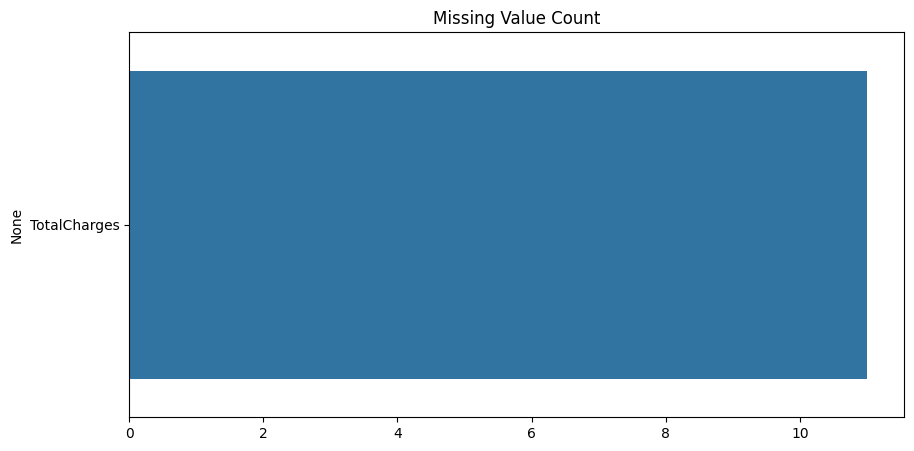

In [74]:
missing_count = df.isnull().sum()

missing_count = missing_count[
    missing_count > 0
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_count.values,
    y=missing_count.index
)

plt.title(
    'Missing Value Count'
)

plt.show()

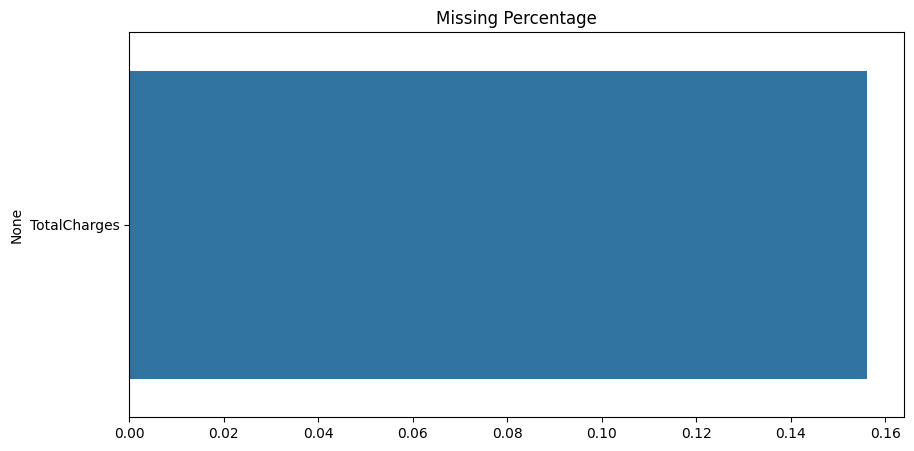

In [75]:
missing_percent = (
    df.isnull().sum()
    / len(df)
)*100

missing_percent = missing_percent[
    missing_percent > 0
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.title(
    'Missing Percentage'
)

plt.show()

In [76]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

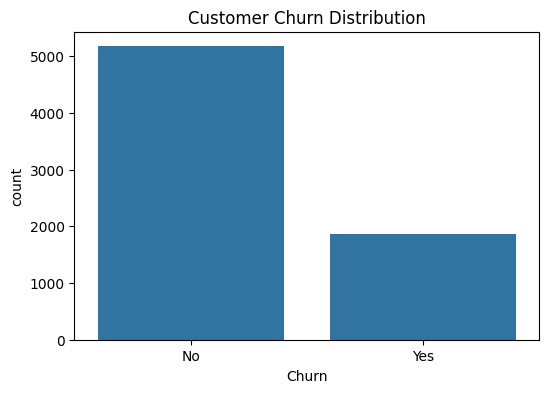

In [77]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title(
    'Customer Churn Distribution'
)

plt.show()

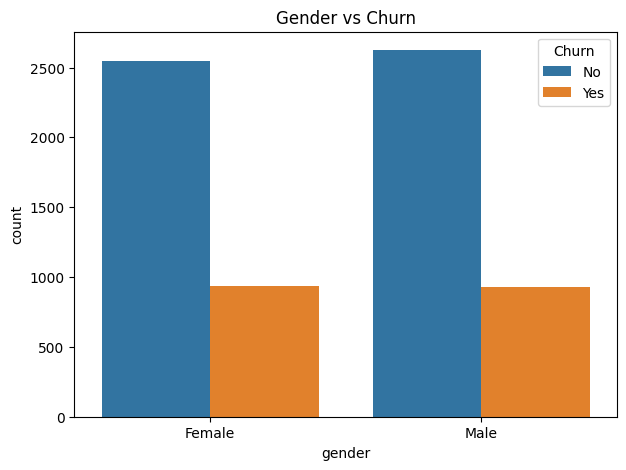

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title(
    'Gender vs Churn'
)

plt.show()

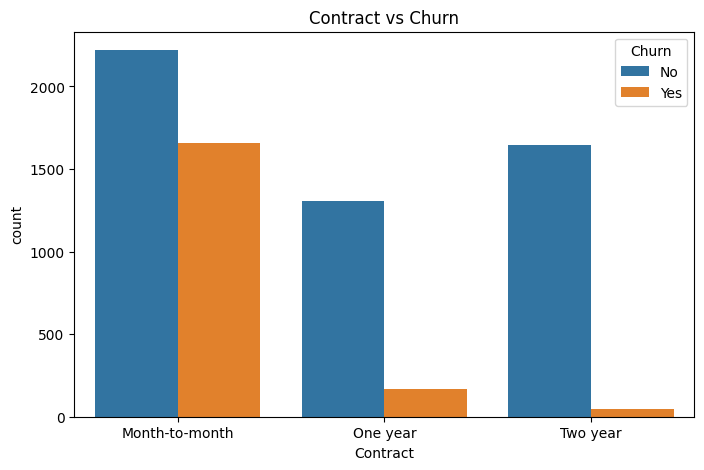

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title(
    'Contract vs Churn'
)

plt.show()

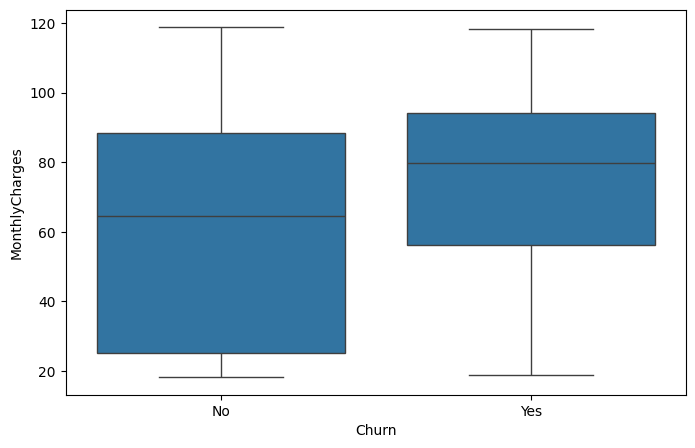

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

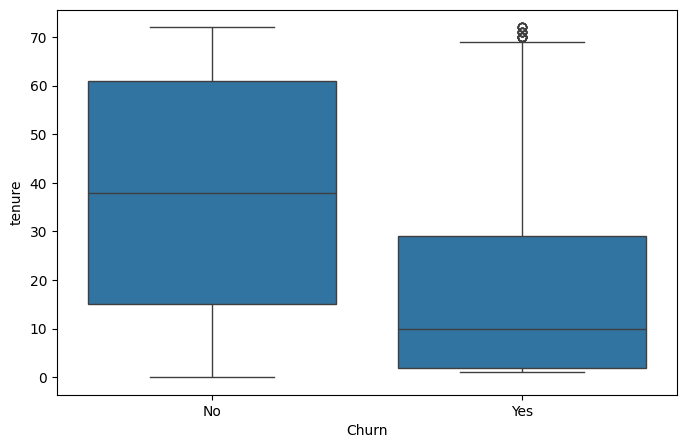

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.show()

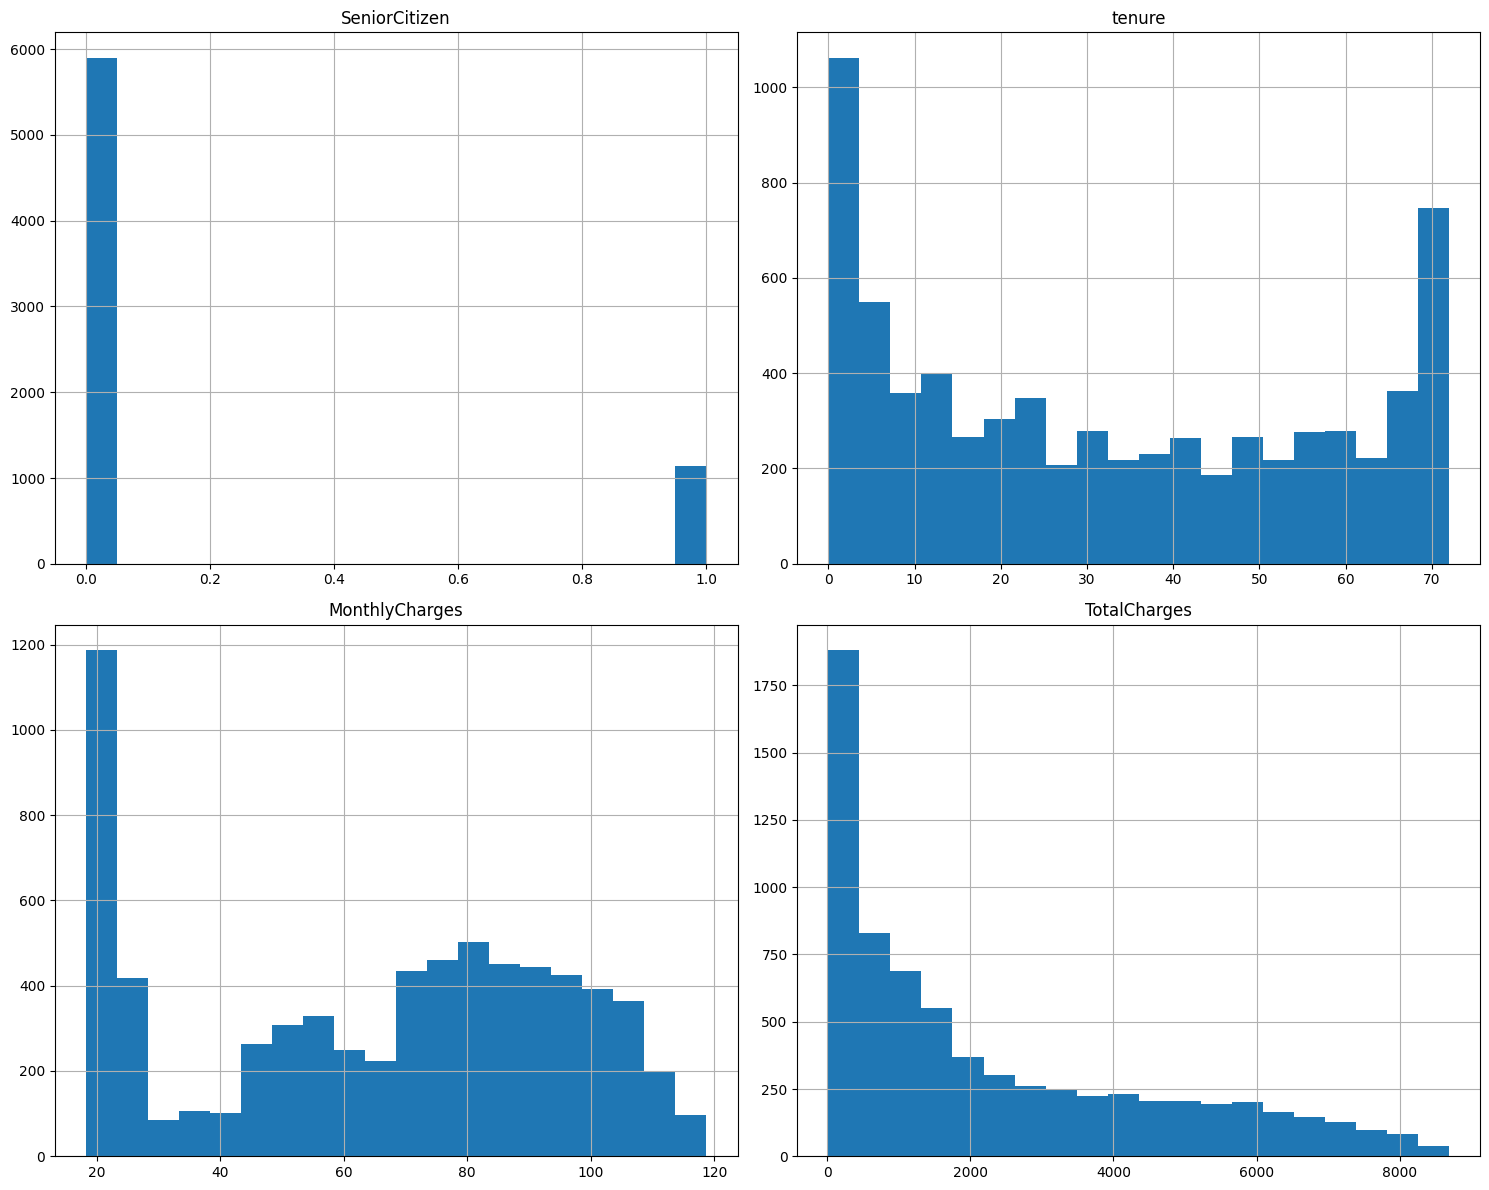

In [82]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

In [83]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col]
        )

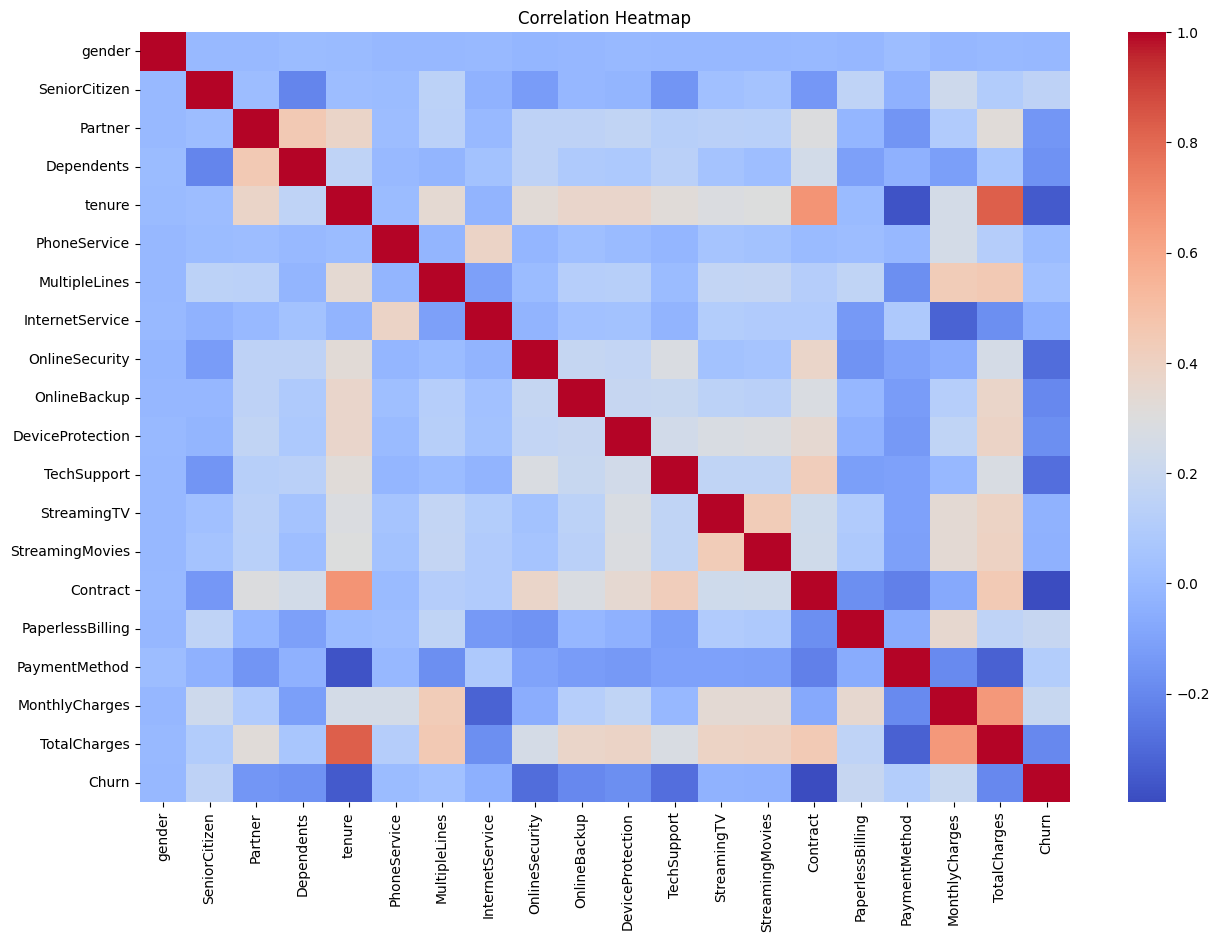

In [84]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

In [85]:
X = df.drop(
    'Churn',
    axis=1
)

y = df['Churn']

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X,y)

importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
18,TotalCharges,0.188243
17,MonthlyCharges,0.181344
4,tenure,0.158132
14,Contract,0.079598
16,PaymentMethod,0.051067
8,OnlineSecurity,0.045266
11,TechSupport,0.043398
0,gender,0.027768
7,InternetService,0.027341
9,OnlineBackup,0.027158


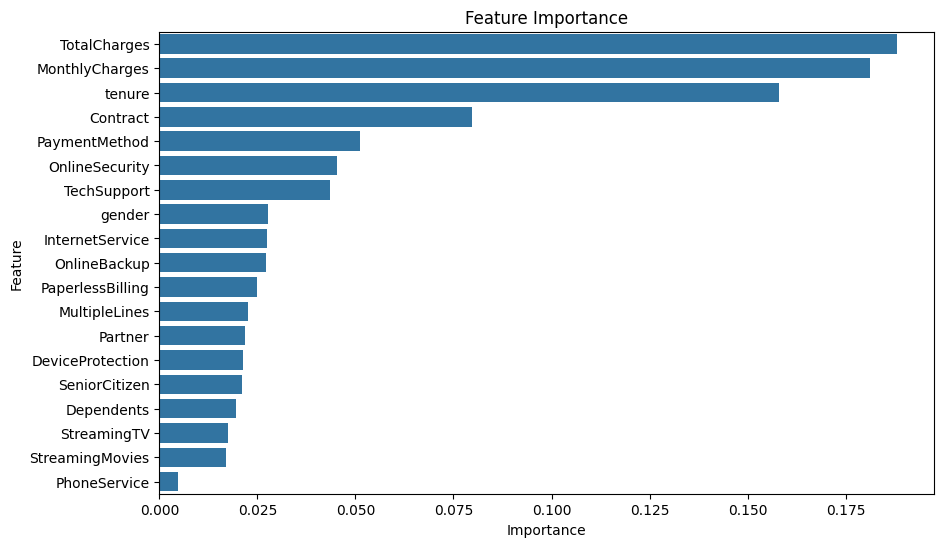

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance'
)

plt.show()

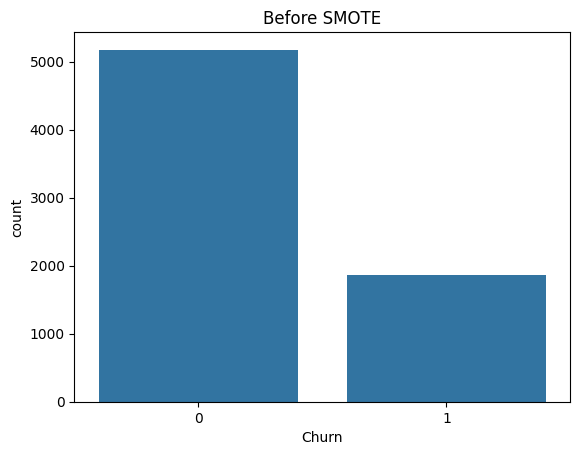

In [87]:
sns.countplot(
    x=y
)

plt.title(
    'Before SMOTE'
)

plt.show()

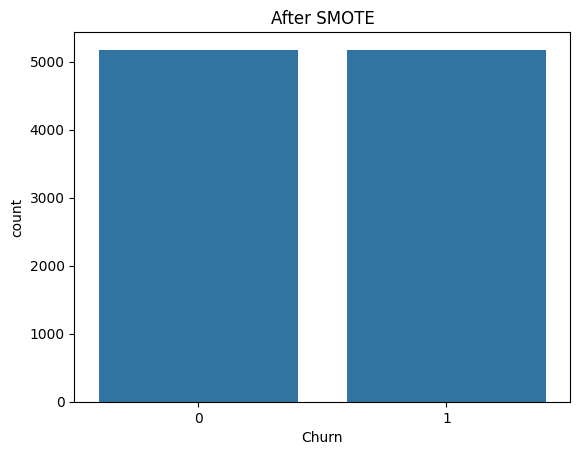

In [88]:
smote = SMOTE(
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y
)
sns.countplot(
    x=y_resampled
)

plt.title(
    'After SMOTE'
)

plt.show()

In [89]:
X_train, X_test, y_train, y_test = train_test_split(

    X_resampled,
    y_resampled,

    test_size=0.20,

    random_state=42,

    stratify=y_resampled
)

In [90]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [103]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Extra Trees":
        ExtraTreesClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "XGBoost":
        XGBClassifier(),

    "Naive Bayes":
        GaussianNB()
}

In [104]:
results = []

best_model = None
best_accuracy = 0
best_name = ""

for name, model in models.items():

    print("\n")
    print("="*60)
    print("TRAINING :", name)
    print("="*60)

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    pre = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([

        name,

        acc,

        pre,

        rec,

        f1

    ])

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print(
        "Accuracy :",
        round(acc,4)
    )

    print(
        "Precision :",
        round(pre,4)
    )

    print(
        "Recall :",
        round(rec,4)
    )

    print(
        "F1 Score :",
        round(f1,4)
    )

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

        best_name = name



TRAINING : Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1035
           1       0.78      0.84      0.81      1035

    accuracy                           0.80      2070
   macro avg       0.81      0.80      0.80      2070
weighted avg       0.81      0.80      0.80      2070

Accuracy : 0.8048
Precision : 0.8067
Recall : 0.8048
F1 Score : 0.8045


TRAINING : KNN
              precision    recall  f1-score   support

           0       0.83      0.72      0.77      1035
           1       0.75      0.86      0.80      1035

    accuracy                           0.79      2070
   macro avg       0.79      0.79      0.79      2070
weighted avg       0.79      0.79      0.79      2070

Accuracy : 0.7879
Precision : 0.7937
Recall : 0.7879
F1 Score : 0.7869


TRAINING : SVM
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1035
           1       0.82     

In [105]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.854589,0.854606,0.854589,0.854588
7,XGBoost,0.844928,0.845098,0.844928,0.844908
5,Extra Trees,0.841063,0.841078,0.841063,0.841061
6,Gradient Boosting,0.834300,0.835465,0.834300,0.834155
2,SVM,0.827536,0.827727,0.827536,0.827511
0,Logistic Regression,0.804831,0.806663,0.804831,0.804539
3,Decision Tree,0.797585,0.797787,0.797585,0.797550
1,KNN,0.787923,0.793687,0.787923,0.786877
8,Naive Bayes,0.782126,0.784227,0.782126,0.781722


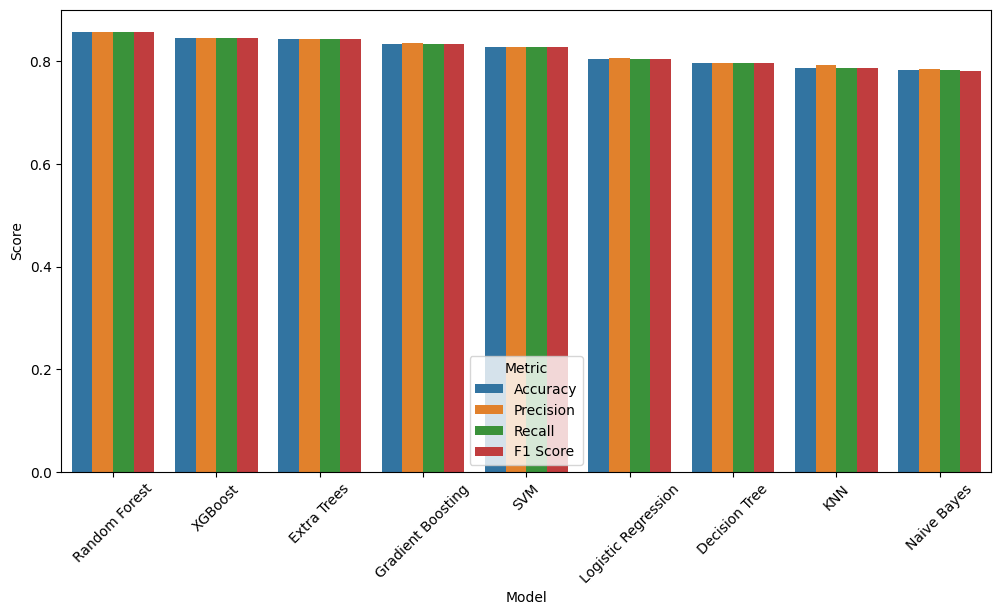

In [94]:
results_melted = results_df.melt(

    id_vars='Model',

    var_name='Metric',

    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.xticks(rotation=45)

plt.show()

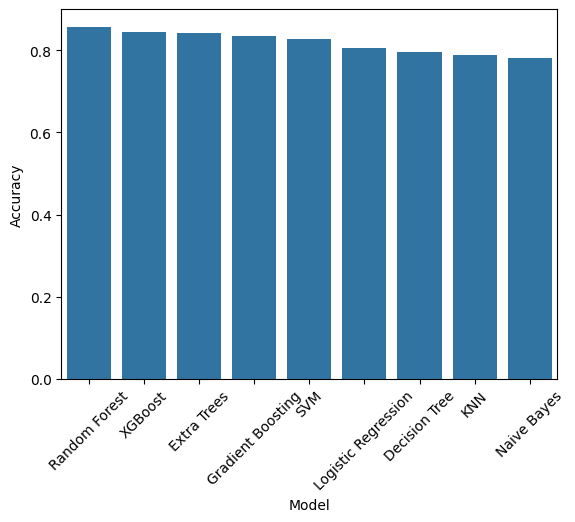

In [95]:
sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.xticks(rotation=45)

plt.show()

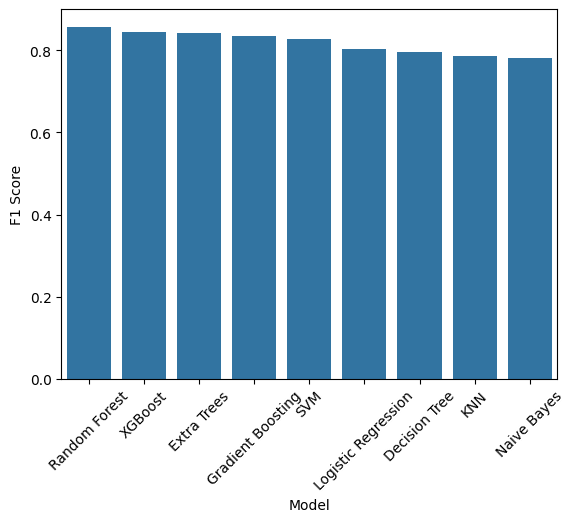

In [96]:
sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score'
)

plt.xticks(rotation=45)

plt.show()

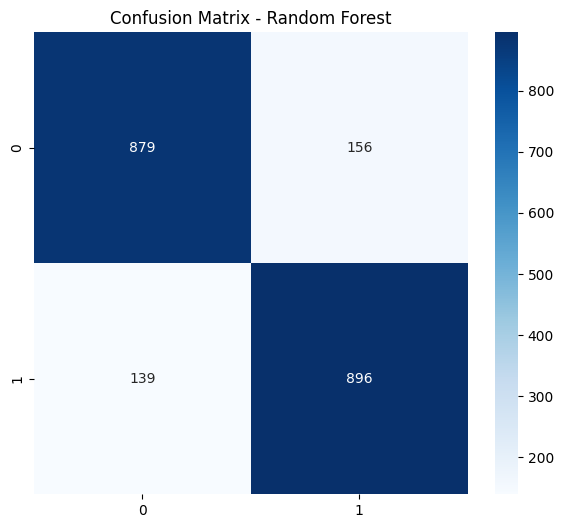

In [97]:
y_pred_best = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_name}'
)

plt.show()

In [98]:
print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(
    "Best Model :",
    best_name
)

print(
    "Best Accuracy :",
    round(
        best_accuracy*100,
        2
    ),
    "%"
)



BEST MODEL
Best Model : Random Forest
Best Accuracy : 85.75 %
